# Access to harm reduction supplies in Chicago

How are these materials dispersed through different neighborhoods in the city? In areas where supplies are available, how accessible are they? 

In [78]:
# Set up 
# Loading packages
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import osmnx as ox
import pandas as pd
import matplotlib.lines as mlines
import requests
import numpy as np
from tqdm import tqdm
from shapely.geometry import Point
import warnings
from shapely.ops import unary_union
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D

# Importing data sets
chi_df = pd.read_csv("data/Chicago Health Atlas Data Download - Community areas.csv")

chi_gdf = gpd.read_file("data/Boundaries - Community Areas_20260520.zip")

pharmacy_df = pd.read_csv("data/Chicago Health Atlas Data Download - Community areas_pharmacies.csv")

url = "https://services7.arcgis.com/A03QrhyHnDaUmK0W/arcgis/rest/services/Harm_Reduction_Boxes/FeatureServer/60/query"

params = {
    "f": "json",
    "where": "Status = 'Active'",
    "outFields": "*",
    "orderByFields": "OBJECTID ASC",
    "resultRecordCount": 8000,
    "outSR": 4326,
}

response = requests.get(url, params=params)
data = response.json()

records = []
for f in data["features"]:
    row = f["attributes"]
    row["longitude"] = f["geometry"]["x"]
    row["latitude"] = f["geometry"]["y"]
    records.append(row)

narcan_df = pd.DataFrame(records)

## Exploring drug and opioid use in Chicago

The Chicago Health Atlas provides a wide variety of public health data by community area. This notebook explores the following metrics about drug/opiate use and demographics in each of the 77 official community areas:
- Number of Emergency Medical Services responses to opioid-related overdoses, 2023
- Number of individuals who died from an opioid overdose at a location in Chicago, even if they did not reside in Chicago, 2023
- Number of Chicago residents who died from an opioid overdose, 2023
- Per capita income, 2020-2024
- Percent of White and non-Hispanic/Latino population, 2020-2024
- Total population, 2020-2024 
- Number of people who died due to poisoning and medical conditions caused by use of legal or illegal drugs or deaths from poisoning due to medically prescribed and other drugs, 2020-2024
- Number of people who died due to drug overdose, 2020-2024
- Drug abuse crimes, 2021-2025

Drug use is hard to measure due to social desirability bias and fear of legal repercussions in survey responses. Here, I've decided to use EMS overdose responses and overdose deaths as a way to approximate greatest need for public health intervention and resources. Similarly, drug use crime data reflects both need for public health services and levels of criminalization in historically over-policed neighborhoods.

In [79]:
# Drug use data 
chi_df = chi_df[chi_df['Layer'] == 'Community area'].reset_index(drop=True)
chi_df = chi_df.rename(columns={
    'EMSOD_2023': 'opioid_ems_2023',
    'MEODL_2023': 'opioid_deaths_chicago_loc_2023', 
    'MEOD_2023': 'opioid_deaths_2023', 
    'PCI_2020-2024': 'per_capita_income',
    'PCT-W_2020-2024':'pct_white',
    'POP_2020-2024': 'population',
    'VRDID_2020-2024':'drug_induced_deaths',
    'VRDO_2020-2024': 'drug_overdose_deaths',
    'CZD_2021-2025': 'drug_abuse_crimes'
})

numeric_cols = ['opioid_ems_2023', 'opioid_deaths_chicago_loc_2023', 'opioid_deaths_2023',
                'per_capita_income', 'pct_white', 'population',
                'drug_induced_deaths', 'drug_overdose_deaths', 'drug_abuse_crimes']

chi_df[numeric_cols] = chi_df[numeric_cols].apply(pd.to_numeric, errors='coerce')
chi_df['GEOID'] = chi_df['GEOID'].astype(int)

To more accurately compare overdoses and overdose mortality across Chicago, I've chosen to normalize these variables per 100,000 in population. This normalization is standard across much of public health research, and allows for easier comparison to other variables such as income. 

In [80]:
# Normalize per 100k population
chi_df['opioid_ems_per_100k'] = (chi_df['opioid_ems_2023'] / chi_df['population']) * 100000
chi_df['drug_overdose_per_100k'] = (chi_df['drug_overdose_deaths'] / chi_df['population']) * 100000
chi_df['drug_abuse_crimes_per_100k'] = (chi_df['drug_abuse_crimes'] / chi_df['population']) * 100000
chi_df['opioid_overdose_per_100k'] = (chi_df['opioid_deaths_2023'] / chi_df['population']) * 100000
chi_df['loc_opioid_overdose_per_100k'] = (chi_df['opioid_deaths_chicago_loc_2023'] / chi_df['population']) * 100000

### Visualizations

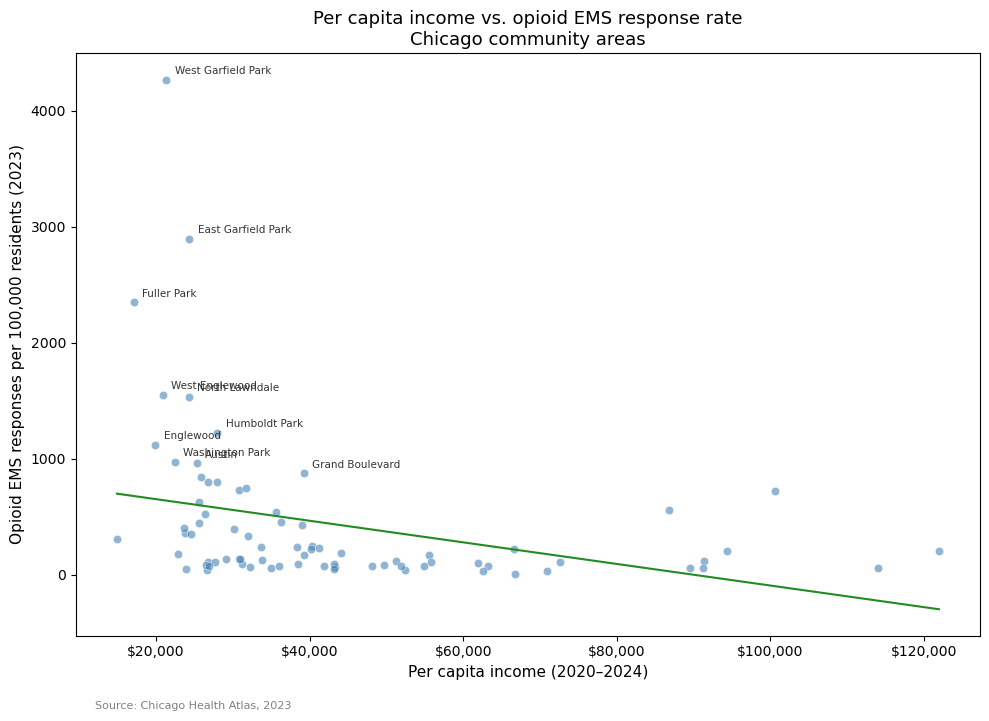

In [81]:
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    chi_df['per_capita_income'],
    chi_df['opioid_ems_per_100k'],
    alpha=0.6,
    color='steelblue',
    edgecolors='white',
    linewidth=0.5
)

# Trend line
z = np.polyfit(chi_df['per_capita_income'], chi_df['opioid_ems_per_100k'], 1)
p = np.poly1d(z)
x_line = np.linspace(chi_df['per_capita_income'].min(), chi_df['per_capita_income'].max(), 200)
ax.plot(x_line, p(x_line), color='forestgreen', linewidth=1.5, linestyle='-')

# Label outliers (top 10 by opioid rate)
for _, row in chi_df.nlargest(10, 'opioid_ems_per_100k').iterrows():
    ax.annotate(
        row['Name'],
        xy=(row['per_capita_income'], row['opioid_ems_per_100k']),
        xytext=(6, 4), textcoords='offset points',
        fontsize=7.5, color='#333'
    )

ax.set_xlabel('Per capita income (2020–2024)', fontsize=11)
ax.set_ylabel('Opioid EMS responses per 100,000 residents (2023)', fontsize=11)
ax.set_title('Per capita income vs. opioid EMS response rate\nChicago community areas', fontsize=13)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

fig.text(0.1, -0.02, 'Source: Chicago Health Atlas, 2023', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

This plot of per capita income and opioid EMS responses highlights the relationship between average income and harm reduction needs for different community areas in Chicago. While increased per capita income is generally associated with lower overdose response rates, there are a few outlier neighborhoods that vastly exceed this prediction for expected relationships. 

In [82]:
# Drug use GDF
chi_gdf = chi_gdf.to_crs(3435)
chi_gdf["community"] = chi_gdf["community"].str.upper()
chi_df['Name'] = chi_df['Name'].str.upper()

cdph_gdf = chi_df.merge(chi_gdf, left_on="Name", right_on="community")
cdph_gdf = gpd.GeoDataFrame(cdph_gdf, geometry='geometry', crs='EPSG:3435')

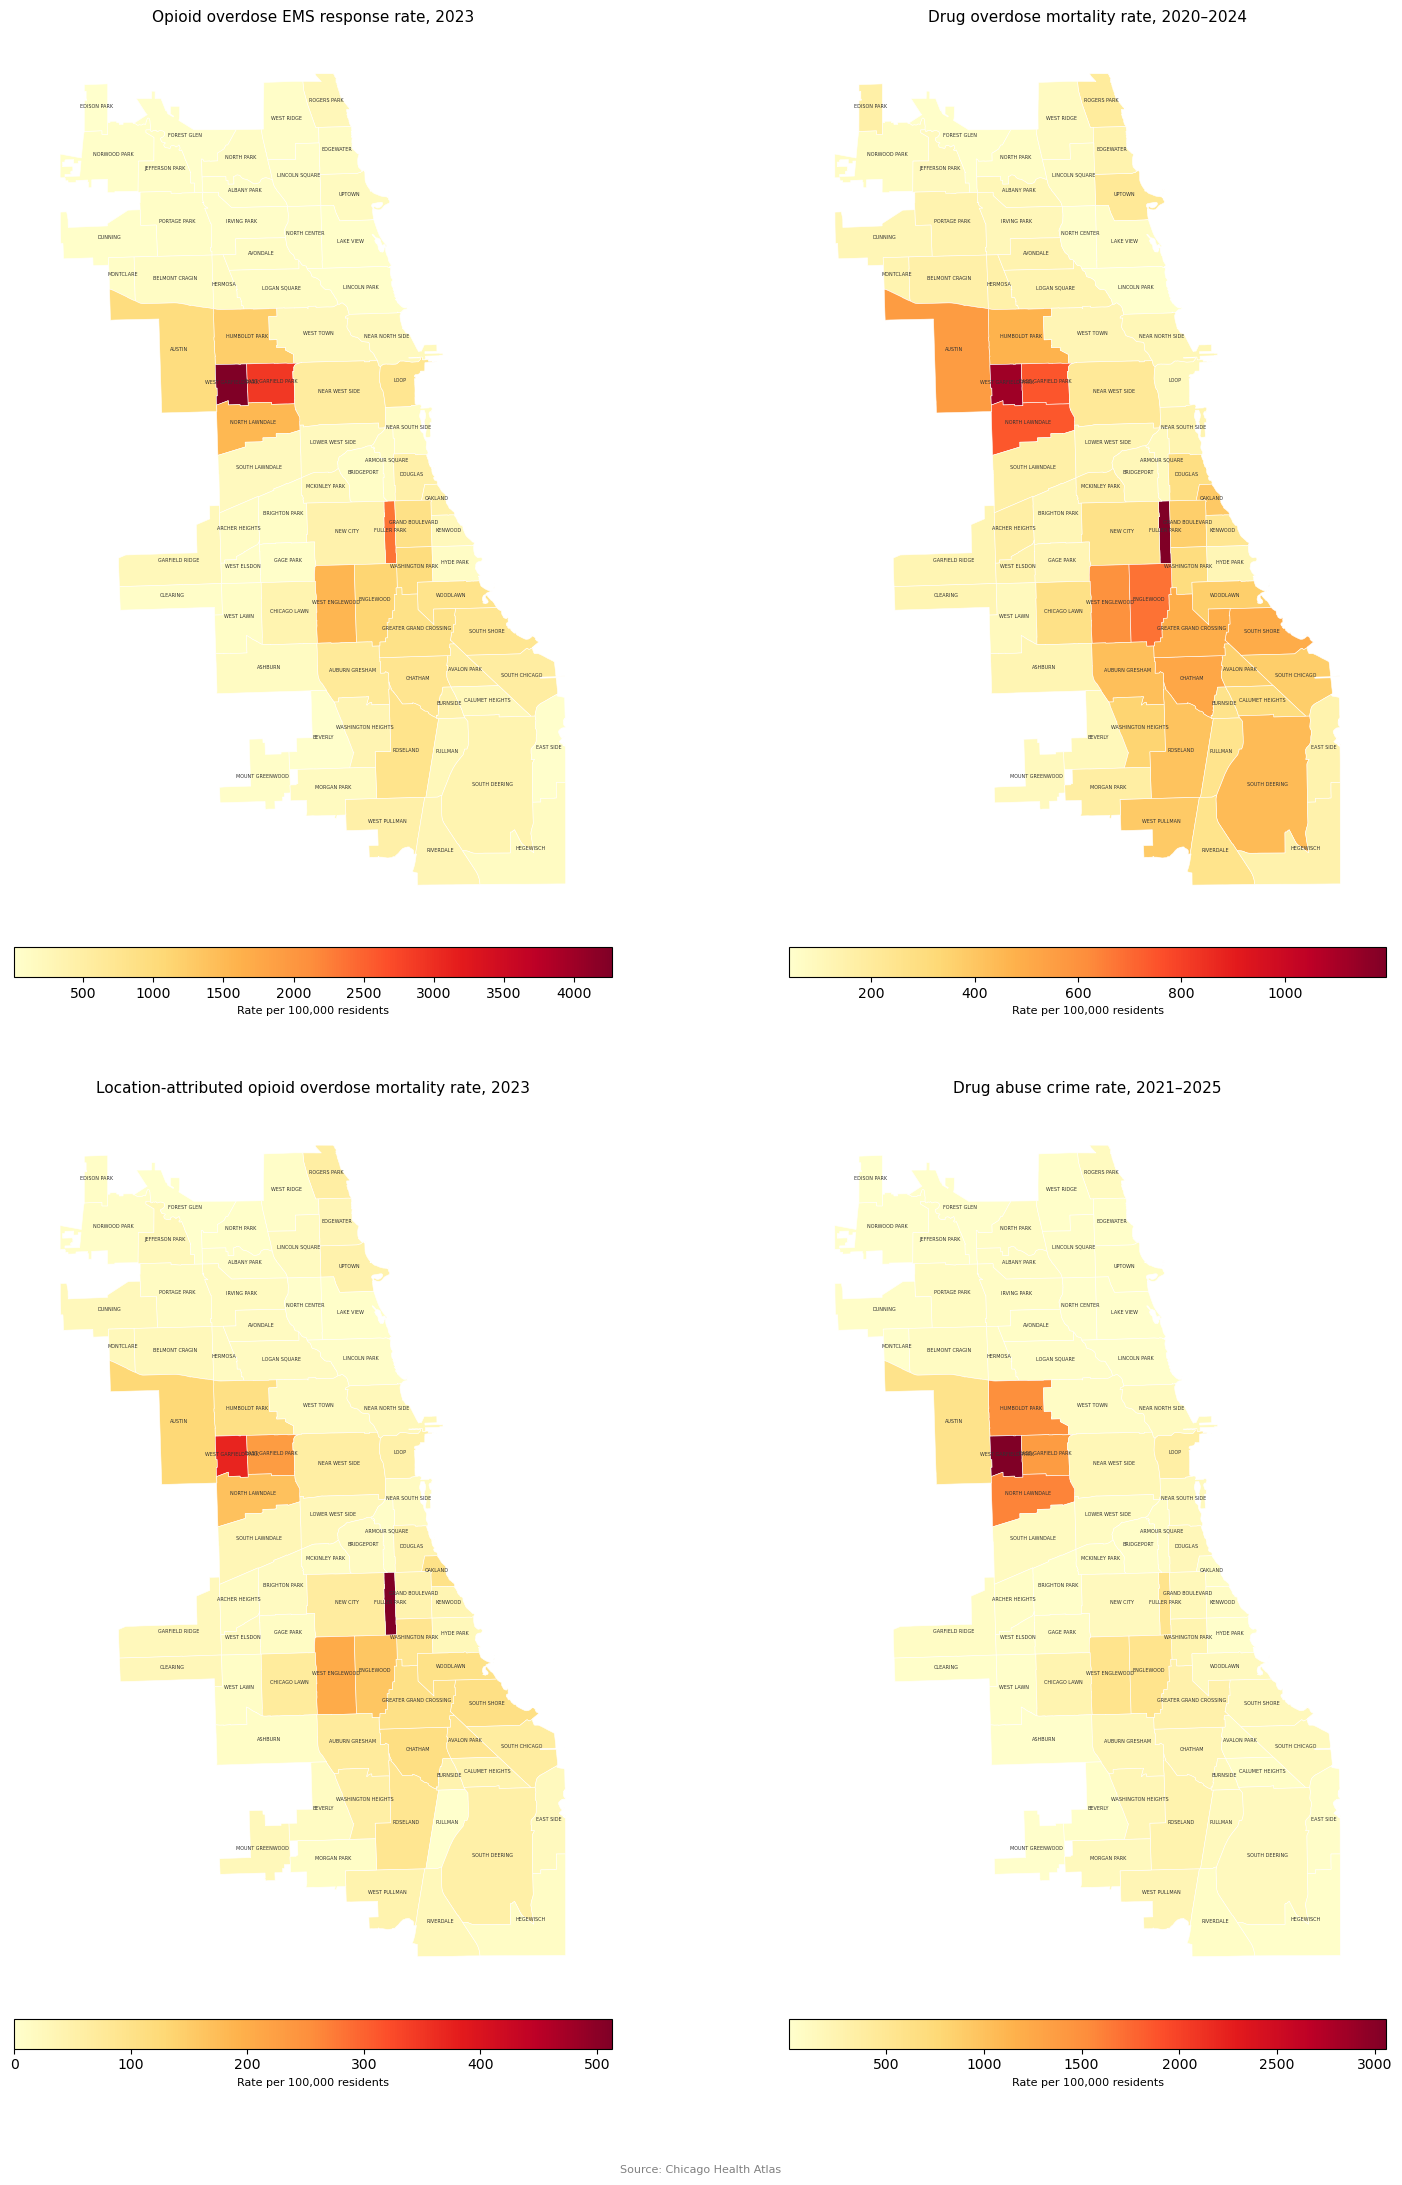

In [83]:
# Visualizing 
fig, axes = plt.subplots(2, 2, figsize=(18, 22))

cols = [
    'opioid_ems_per_100k',
    'drug_overdose_per_100k',
    'loc_opioid_overdose_per_100k',
    'drug_abuse_crimes_per_100k'
]
titles = [
    'Opioid overdose EMS response rate, 2023',
    'Drug overdose mortality rate, 2020–2024',
    'Location-attributed opioid overdose mortality rate, 2023',
    'Drug abuse crime rate, 2021–2025'
]

for ax, col, title in zip(axes.flat, cols, titles):
    cdph_gdf.plot(
        column=col,
        ax=ax,
        cmap='YlOrRd',
        linewidth=0.4,
        edgecolor='white',
        legend=False
    )

    # Colorbar
    sm = ScalarMappable(
        cmap='YlOrRd',
        norm=Normalize(vmin=cdph_gdf[col].min(), vmax=cdph_gdf[col].max())
    )
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', shrink=0.6, pad=0.02)
    cbar.set_label('Rate per 100,000 residents', fontsize=8)

    # Community area labels
    for _, row in cdph_gdf.iterrows():
        if row.geometry and not pd.isna(row.get(col)):
            centroid = row.geometry.centroid
            ax.annotate(
                row['community'],
                xy=(centroid.x, centroid.y),
                fontsize=3.5, ha='center', color='#333'
            )

    ax.set_title(title, fontsize=11, pad=8)
    ax.axis('off')

fig.text(
    0.5, 0.01,
    'Source: Chicago Health Atlas',
    ha='center', fontsize=8, color='gray'
)

plt.tight_layout()
plt.show()

Expands from only opioid related calls to all drug mortality. Fuller Park outlier partially due to small population.

## Exploring harm reduction resources 

Narcan (generic name naloxone) is an opioid overdose reversal medication. It is very widely available across Chicago, including at all public library branches. Narcan is a lifesaving resource that should be easily and openly available. However, Narcan only helps users after an opiate overdose has already occured. Narcan is also only effective in combatting opiate overdoses, meaning that overdoses from other drugs, particularly xylazine, cannot be treated using Narcan. Harm reduction supplies like drug testing strips are a precautionary tool that allows users to test drugs for the presence of other drugs or common contaiminents before use. Various different kinds of test strips are available at Chicago Public Libraries, Chicago Department of Public Health Vending Machines, and harm reduction resource sites such as Vivent, the Puerto Rico Project, Transforming Reentry Services, UIUC's Community Outreach Intervention Programs (COIP), and the Chicago Recovery Alliance. Syringe services programs are another public health and harm reduction service that provides people who inject drugs with clean and sterile syringes, and frequently connects users to other services or harm reduction supplies. Vivent, the Puerto Rico Project, Transforming Reentry, COIP, and Chicago Recovery Alliance are Chicago's primary syringe services programs. Though the majority of these operate out of fixed locations, the Puerto Rico Project and Chicago Recovery Alliance are mobile resources which move between community areas everyday. What does access to both Narcan and other preventative harm reduction supplies look like for Chicagoans? 

In [84]:
# Drop narcan sites outside of Chicago to avoid skewing visualization
narcan_df = narcan_df[narcan_df["COMMUNITY_AREA"].notna()]
narcan_df['COMMUNITY_AREA'] = narcan_df['COMMUNITY_AREA'].str.upper()

narcan_points = gpd.GeoDataFrame(
    narcan_df,
    geometry=gpd.points_from_xy(narcan_df['longitude'], narcan_df['latitude']),
    crs='EPSG:4326'
).to_crs('EPSG:3435')

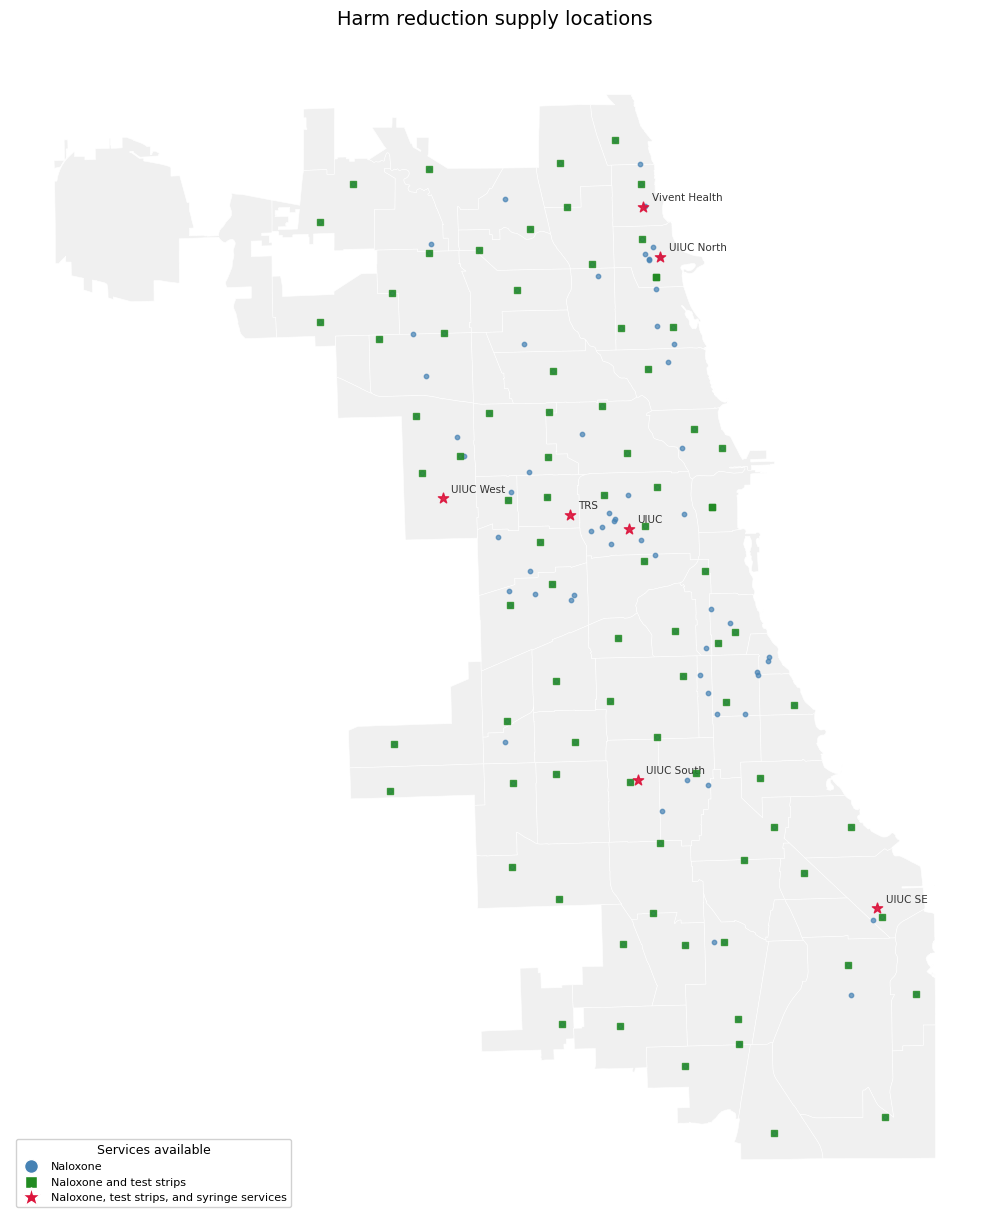

In [85]:
fig, ax = plt.subplots(figsize=(10, 13))

# Base map
chi_gdf.plot(ax=ax, color='#f0f0f0', edgecolor='white', linewidth=0.4)

# All Narcan/naloxone locations
narcan_points.plot(
    ax=ax,
    color='steelblue',
    marker='o',
    markersize=10,
    alpha=0.7,
    zorder=3
)

# Naloxone and test strip locations
filtered_points = narcan_points[
    narcan_points['LOCATION_TYPE'].isin(['CDPH Vending Machine', 'Chicago Public Library'])
]
filtered_points.plot(
    ax=ax,
    color='forestgreen',
    marker='s',
    markersize=20,
    alpha=0.8,
    zorder=4
)

# Naloxone, test strips, and syringe services locations
sites = {
    'Vivent Health': (41.98319673567818, -87.65989684787584),
    'TRS': (41.874043410004965, -87.69601255952014),
    'UIUC': (41.86888220860609, -87.66778776132946),
    'UIUC North': (41.965356537281195, -87.65199487791106),
    'UIUC West': (41.880200592318154, -87.75617607482222),
    'UIUC South': (41.77976758362488, -87.66465133249834),
    'UIUC SE': (41.73344191199558, -87.55156797482948),
}
sites_gdf = gpd.GeoDataFrame(
    {'name': list(sites.keys())},
    geometry=[Point(lon, lat) for lat, lon in sites.values()],
    crs='EPSG:4326'
).to_crs('EPSG:3435')

sites_gdf.plot(
    ax=ax,
    color='crimson',
    marker='*',
    markersize=60,
    alpha=0.9,
    zorder=5
)
for _, row in sites_gdf.iterrows():
    ax.annotate(
        row['name'],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(6, 4), textcoords='offset points',
        fontsize=7.5, color='#333'
    )

# Legend
legend_elements = [
    mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
                  markersize=10, label='Naloxone'),
    mlines.Line2D([0], [0], marker='s', color='w', markerfacecolor='forestgreen',
                  markersize=9, label='Naloxone and test strips'),
    mlines.Line2D([0], [0], marker='*', color='w', markerfacecolor='crimson',
                  markersize=14, label='Naloxone, test strips, and syringe services'),
]
ax.legend(handles=legend_elements, title='Services available',
          fontsize=8, title_fontsize=9, loc='lower left', framealpha=0.9)

ax.set_title('Harm reduction supply locations', fontsize=14, pad=12)
ax.axis('off')

plt.tight_layout()
plt.show()

Comparison to other community resources

The naloxone access map already includes community resources like hospitals and public libraries. Naloxone is also available in pharmacies through Chicago public health mandate. How does access to broader healthcare services like pharmacies differ from access to harm reduction materials? 

In [86]:
pharmacy_df = pharmacy_df[pharmacy_df['Layer'] == 'Community area'].reset_index(drop=True)
pharmacy_df = pharmacy_df.rename(columns={
    'NXP_2021': 'pharmacies_per_cap'
})
pharmacy_df['pharmacies_per_cap'] = pharmacy_df['pharmacies_per_cap'].apply(pd.to_numeric, errors='coerce')
pharmacy_df['GEOID'] = pharmacy_df['GEOID'].astype(int)

In [87]:
pharmacy_df['Name'] = pharmacy_df['Name'].str.upper()

pharmacy_gdf = pharmacy_df.merge(cdph_gdf, left_on="Name", right_on="community")
pharmacy_gdf = gpd.GeoDataFrame(pharmacy_gdf, geometry='geometry', crs='EPSG:3435')

In [88]:
# Aggregate harm reduction sites to community area by 100k population for comparison
hr_counts = narcan_points.groupby('COMMUNITY_AREA').size().reset_index(name='hr_site_count')
merged_gdf = pharmacy_gdf.merge(hr_counts, left_on='community', right_on='COMMUNITY_AREA', how='left')
merged_gdf['hr_site_count'] = merged_gdf['hr_site_count'].fillna(0)
merged_gdf['hr_per_100k'] = (merged_gdf['hr_site_count'] / merged_gdf['population']) * 100000

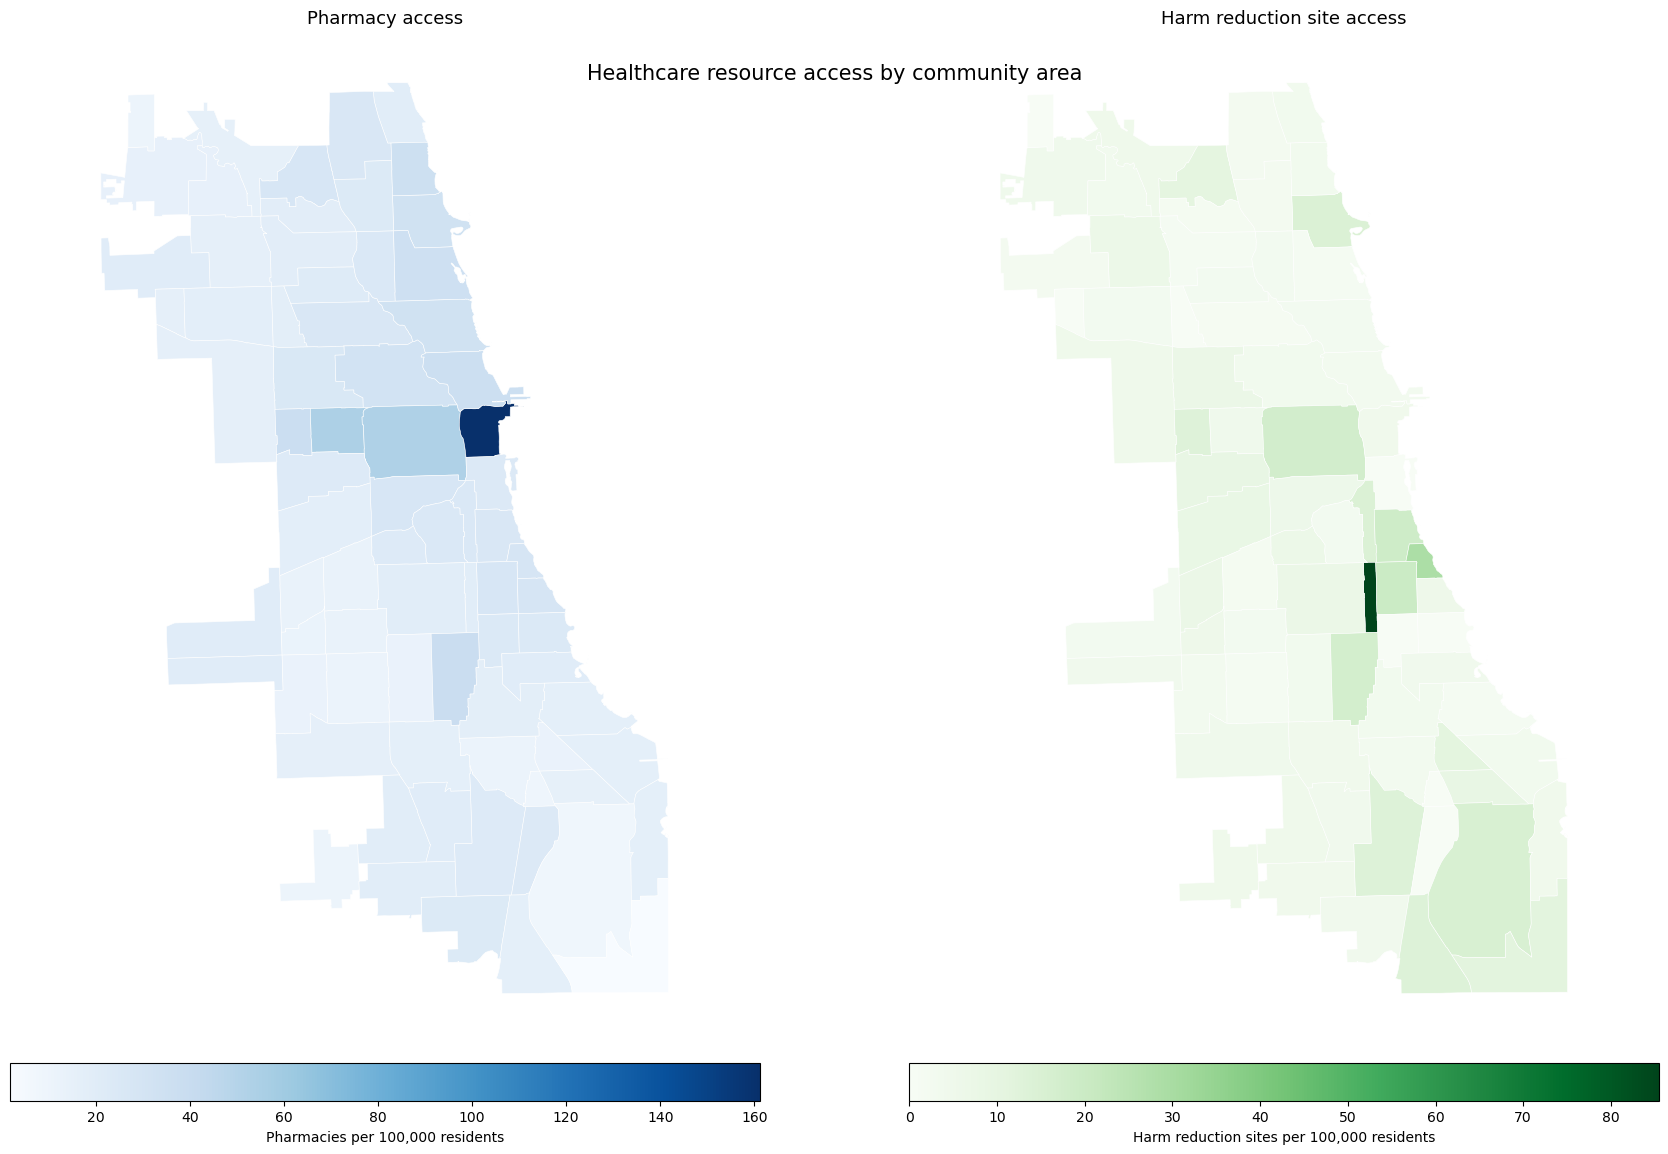

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(20, 13))

vmin_pharm = merged_gdf['pharmacies_per_cap'].min()
vmax_pharm = merged_gdf['pharmacies_per_cap'].max()
vmin_hr = merged_gdf['hr_per_100k'].min()
vmax_hr = merged_gdf['hr_per_100k'].max()

# Pharmacies
merged_gdf.plot(
    column='pharmacies_per_cap',
    ax=axes[0],
    cmap='Blues',
    linewidth=0.4,
    edgecolor='white',
    legend=True,
    vmin=vmin_pharm,
    vmax=vmax_pharm,
    legend_kwds={'label': 'Pharmacies per 100,000 residents',
                 'orientation': 'horizontal', 'shrink': 0.7, 'pad': 0.02}
)
axes[0].set_title('Pharmacy access', fontsize=13, pad=10)
axes[0].axis('off')

# Harm reduction sites
merged_gdf.plot(
    column='hr_per_100k',
    ax=axes[1],
    cmap='Greens',
    linewidth=0.4,
    edgecolor='white',
    legend=True,
    vmin=vmin_hr,
    vmax=vmax_hr,
    legend_kwds={'label': 'Harm reduction sites per 100,000 residents',
                 'orientation': 'horizontal', 'shrink': 0.7, 'pad': 0.02}
)

axes[1].set_title('Harm reduction site access', fontsize=13, pad=10)
axes[1].axis('off')

fig.suptitle('Healthcare resource access by community area',
             fontsize=15, y=0.92)

plt.tight_layout()
plt.show()

## Supply Access by neighborhood

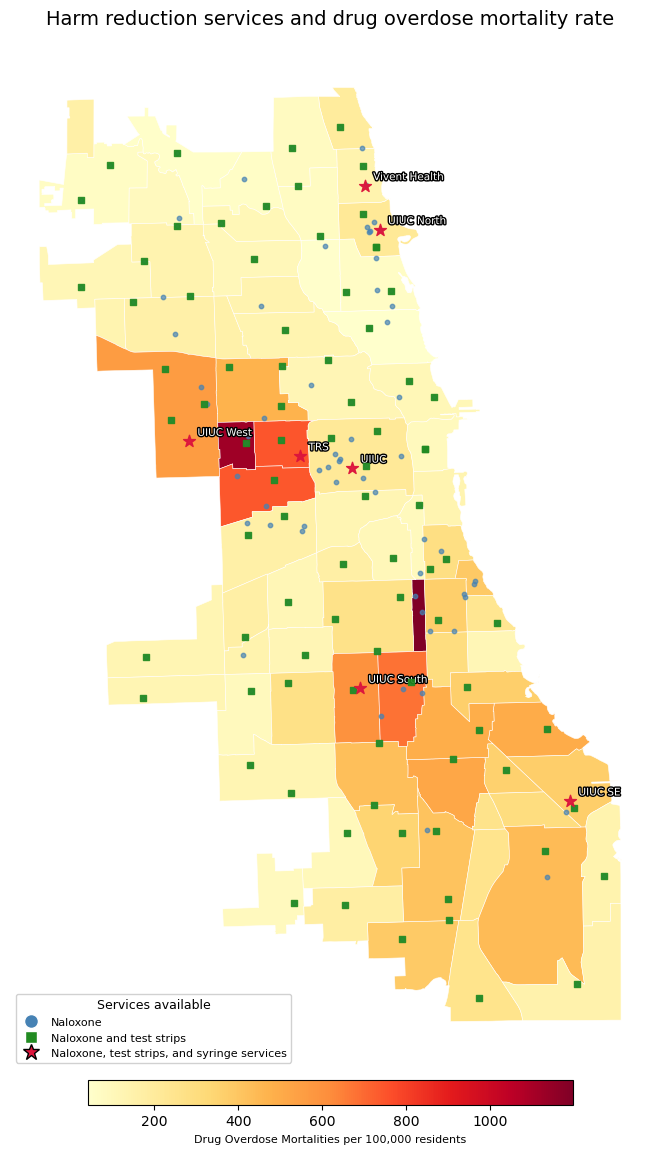

In [90]:
# Identifying areas of need
fig, ax = plt.subplots(figsize=(10, 13))

# Base map
cdph_gdf.plot(
    column='drug_overdose_per_100k',
    ax=ax,
    cmap='YlOrRd',
    linewidth=0.4,
    edgecolor='white',
    legend=False,      
    zorder=1
)

# Colorbar
sm = ScalarMappable(
    cmap='YlOrRd',
    norm=Normalize(vmin=cdph_gdf['drug_overdose_per_100k'].min(),
                   vmax=cdph_gdf['drug_overdose_per_100k'].max())
)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', shrink=0.5, pad=0.01)
cbar.set_label('Drug Overdose Mortalities per 100,000 residents', fontsize=8)

# All naloxone locations
narcan_points.plot(
    ax=ax, color='steelblue', marker='o',
    markersize=10, alpha=0.7, zorder=3
)

# Naloxone and test strip locations
filtered_points = narcan_points[
    narcan_points['LOCATION_TYPE'].isin(['CDPH Vending Machine', 'Chicago Public Library'])
]
filtered_points.plot(
    ax=ax, color='forestgreen', marker='s',
    markersize=20, alpha=0.9, zorder=4
)

# Naloxone, test strips, and syringe services locations
sites = {
    'Vivent Health': (41.98319673567818, -87.65989684787584),
    'TRS':           (41.874043410004965, -87.69601255952014),
    'UIUC':          (41.86888220860609, -87.66778776132946),
    'UIUC North':    (41.965356537281195, -87.65199487791106),
    'UIUC West':     (41.880200592318154, -87.75617607482222),
    'UIUC South':    (41.77976758362488, -87.66465133249834),
    'UIUC SE':       (41.73344191199558, -87.55156797482948),
}
sites_gdf = gpd.GeoDataFrame(
    {'name': list(sites.keys())},
    geometry=[Point(lon, lat) for lat, lon in sites.values()],
    crs='EPSG:4326'
).to_crs('EPSG:3435')

sites_gdf.plot(
    ax=ax, color='crimson', marker='*',
    markersize=80, alpha=0.95, zorder=5
)
for _, row in sites_gdf.iterrows():
    ax.annotate(
        row['name'],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(6, 4), textcoords='offset points',
        fontsize=7.5, color='white',
        path_effects=[
            __import__('matplotlib.patheffects', fromlist=['withStroke'])
            .withStroke(linewidth=2, foreground='black')
        ]
    )

# Legend
legend_elements = [
    mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
                  markersize=10, label='Naloxone'),
    mlines.Line2D([0], [0], marker='s', color='w', markerfacecolor='forestgreen',
                  markersize=8, label='Naloxone and test strips'),
    mlines.Line2D([0], [0], marker='*', color='w', markerfacecolor='crimson',
                  markeredgecolor='black', markersize=12,
                  label='Naloxone, test strips, and syringe services'),
]
ax.legend(handles=legend_elements, title='Services available',
          fontsize=8, title_fontsize=9, loc='lower left', framealpha=0.9)

ax.set_title('Harm reduction services and drug overdose mortality rate',
             fontsize=14, pad=12)
ax.axis('off')

plt.tight_layout()
plt.show()

For the cluster of community areas on the West side of the city, how easy is it to access naloxone in the event of an emergency? 

Building isochrones: 100%|██████████| 15/15 [00:02<00:00,  5.65it/s]


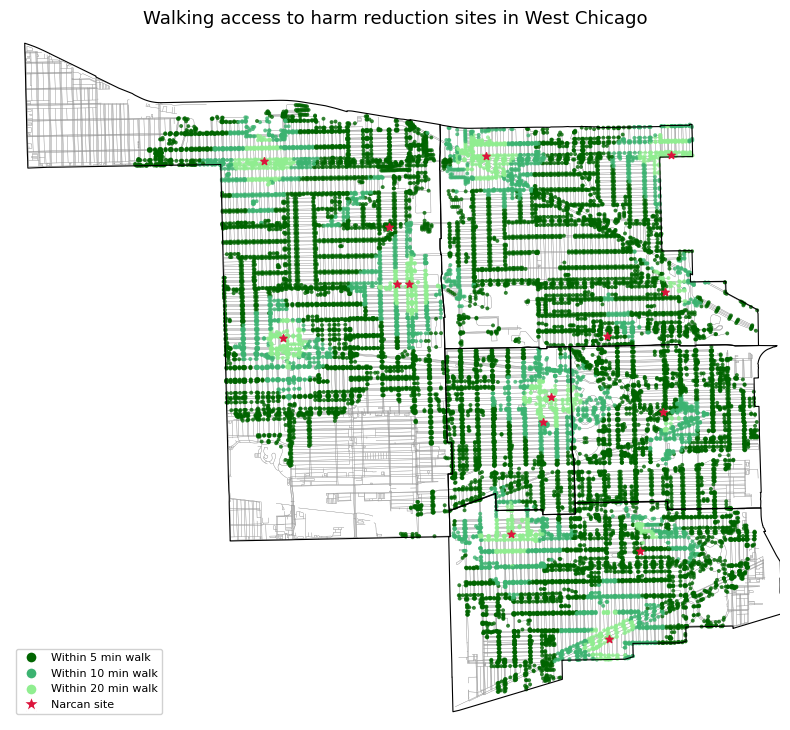

In [91]:
# Isochrone walking distance to naloxone resources for high need cluster

warnings.filterwarnings("ignore", category=RuntimeWarning, module="shapely")

avg_feet_per_minute = 276
trip_times = [5, 10, 20]
iso_colors = ["darkgreen", "mediumseagreen", "lightgreen"]

# Cluster high burden/need neighborhoods on West side 
west_side_cluster = [
    'AUSTIN',
    'HUMBOLDT PARK',
    'WEST GARFIELD PARK',
    'EAST GARFIELD PARK',
    'NORTH LAWNDALE'
]

high_burden_areas = merged_gdf[merged_gdf['community'].isin(west_side_cluster)]

# Filter to cluster and download network
high_burden_4326 = high_burden_areas.to_crs("EPSG:4326").copy()
high_burden_polygon = unary_union(high_burden_4326.geometry)

walk_graph = ox.graph_from_polygon(high_burden_polygon, network_type="walk")

for source, target, key, data in walk_graph.edges(data=True, keys=True):
    data["length_ft"] = data["length"] * 3.28084
    data["time"] = data["length_ft"] / avg_feet_per_minute

# Filter points to West side
top_areas_list = high_burden_areas['community'].str.upper().tolist()
narcan_4326 = narcan_points.to_crs("EPSG:4326")
narcan_filtered = narcan_4326[narcan_4326['COMMUNITY_AREA'].isin(top_areas_list)]

# Connect naloxone sites to nearest network node
hr_nodes = ox.nearest_nodes(
    walk_graph,
    X=narcan_filtered.geometry.x,
    Y=narcan_filtered.geometry.y
)

# Build isochrones
node_colors = {}
sorted_trip_times = sorted(trip_times, reverse=True)

for hr_node in tqdm(hr_nodes, desc="Building isochrones"):
    for trip_time, color in zip(sorted_trip_times, iso_colors):
        subgraph = nx.ego_graph(
            walk_graph, hr_node, radius=trip_time, distance="time"
        )
        for node in subgraph.nodes():
            node_colors[node] = color

# Plot
node_color = []
node_size = []
for node in walk_graph.nodes():
    if node in node_colors:
        node_color.append(node_colors[node])
        node_size.append(8)
    else:
        node_color.append("none")
        node_size.append(0)

fig, ax = ox.plot_graph(
    walk_graph,
    node_color=node_color,
    node_size=node_size,
    node_alpha=0.8,
    node_zorder=2,
    bgcolor="w",
    edge_linewidth=0.2,
    edge_color="#999999",
    show=False,
    close=False
)

# Community area boundaries
high_burden_4326.plot(
    ax=ax, facecolor="none", edgecolor="black", linewidth=0.8, zorder=3
)

# Naloxone points
narcan_filtered.plot(
    ax=ax, color="crimson", markersize=30, marker="*", zorder=5, label="Narcan/naloxone site"
)

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='darkgreen',
           markersize=8, label='Within 5 min walk'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='mediumseagreen',
           markersize=8, label='Within 10 min walk'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgreen',
           markersize=8, label='Within 20 min walk'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='crimson',
           markersize=12, label='Narcan site'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=8, framealpha=0.9)
ax.set_title(
    'Walking access to harm reduction sites in West Chicago',
    fontsize=13
)

plt.tight_layout()
plt.show()

### References: 
- "Support for evidence-informed opioid policies and interventions: The role of racial attitudes, political affiliation, and opioid stigma" https://doi.org/10.1016/j.ypmed.2022.107034 
- "America’s opioid crisis: the need for an integrated public health approach" https://www.nature.com/articles/s41398-020-0847-1#Sec7 
- "Public Views About Opioid Overdose and People With Opioid Use Disorder" https://jamanetwork.com/journals/jamanetworkopen/fullarticle/2844036 
- "Drug treatment perspectives and experiences among family and friends of people who use illicit opioids: A mixed methods study" https://doi.org/10.1016/j.josat.2023.209023
- Find Narcan Near You! - https://chicago.maps.arcgis.com/home/item.html?id=5a0b191cdc18446e8691fcd74b34cba5 
- Information on xylazine - https://nida.nih.gov/research-topics/xylazine#substances
- CDPH vending machine info - https://www.chicago.gov/city/en/depts/cdph/provdrs/behavioral_health/supp_info/vending-machine-survey.html#docaccess-d0551a918b29252ff9a57dfba4835912
- Don't Die High - https://www.chicago.gov/city/en/depts/cdph/provdrs/infectious_disease/supp_info/dont-die-high.html
- Cook County Health vending machines - https://cookcountyhealth.org/naloxone/#elementor-toc__heading-anchor-2 
- UIUC Community Outreach Intervention Project - https://coip.uic.edu/about-coip/
- Transforming Reentry Services Harm Reduction - https://transformingreentry.org/harm-reduction/ 
- NASEN Syringe Services Programs - https://nasen.org/?go=process 

AI Attribution: I used AI to help improve the aesthetics of my visualizations, specifically for improving the style and legibility of labels, legends, and color bars. I also used AI for troubleshooting issues, including accessing the Chicago Department of Public Health ArcGIS API for their "Find Narcan Near You!" data and bounding the isochrone walking distance map to only the most affected cluster of neighborhoods in the city. 